In [ ]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import files

print('Please select file to upload:')
uploaded = files.upload()

Please select file to upload:


Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [ ]:
df1 = pd.read_csv("historical_data.csv")
df2 = pd.read_csv("fear_greed_index.csv")

In [ ]:
#Basic Cleaning
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
# Encode Categorical Variables
model_df = df.copy()

# List of categorical columns
categorical_cols = model_df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

In [ ]:
model_df.fillna(model_df.median(numeric_only=True), inplace=True)
print("Missing values in model_df after median imputation:")
display(model_df.isnull().sum()[model_df.isnull().sum() > 0])

Missing values in model_df after median imputation:


,0


In [ ]:
# Check for missing values in model_df
missing_values = model_df.isnull().sum()
display(missing_values[missing_values > 0])

,0


In [ ]:
#Define the feature and target
X = model_df.drop(columns=['Closed PnL'])
y = model_df['Closed PnL']
print("X and y redefined from imputed model_df.")

X and y redefined from imputed model_df.


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Train-test split re-executed with updated X and y.")

Train-test split re-executed with updated X and y.


In [ ]:
# Model 1 : Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Linear Regression model re-fitted successfully.")

Linear Regression model re-fitted successfully.


In [ ]:
# Evaluate the Model
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Model Performance:\n")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Linear Regression Model Performance:

Mean Absolute Error (MAE): 112.4752
Mean Squared Error (MSE): 1257981.4166
R-squared (R2): -0.0031


In [ ]:
# Evaluation
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test,y_pred_lr))

print("RMSE :", np.sqrt(mean_squared_error(y_test,y_pred_lr)))

print("R2 Score :", r2_score(y_test,y_pred_lr))

Linear Regression
MAE : 112.47518673946637
RMSE : 1121.5977071134632
R2 Score : -0.003077122381512698


# Model 2 Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
#Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("Random Forest Regressor")

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"R-squared (R2): {r2_rf:.4f}")

Random Forest Regressor
Mean Absolute Error (MAE): 36.2678
Mean Squared Error (MSE): 959859.8543
Root Mean Squared Error (RMSE): 979.7244
R-squared (R2): 0.2346


In [ ]:
# XG Boost Regressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_regressor = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb_regressor.fit(X_train, y_train)

y_pred_xgb = xgb_regressor.predict(X_test)

print("XGBoost Regressor")

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"R-squared (R2): {r2_xgb:.4f}")

XGBoost Regressor
Mean Absolute Error (MAE): 65.7981
Mean Squared Error (MSE): 867654.7714
Root Mean Squared Error (RMSE): 931.4799
R-squared (R2): 0.3082


In [ ]:
# Feature Importance
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
7,Start Position,0.206959
4,Size USD,0.155097
10,Order ID,0.109988
3,Size Tokens,0.088429
12,Fee,0.084012
2,Execution Price,0.069122
6,Timestamp IST,0.058503
0,Account,0.055907
8,Direction,0.055126
13,Trade ID,0.049086


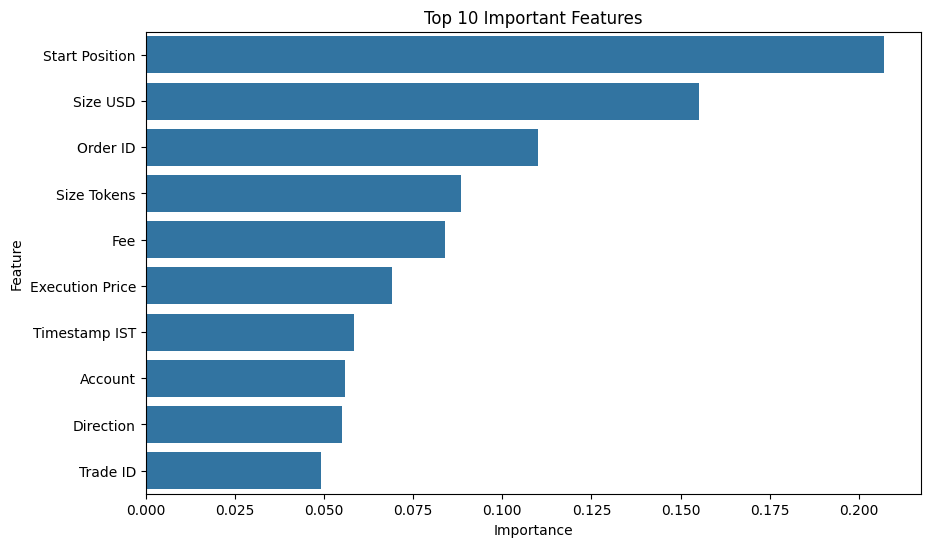

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

In [ ]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(XGBRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [ ]:
# Evaluate the Best Model from Grid Search
y_pred_best = best_model.predict(X_test)

print("Optimized XGBoost Regressor Performance:")
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Best Parameters: {grid.best_params_}")
print(f"Mean Absolute Error (MAE): {mae_best:.4f}")
print(f"Mean Squared Error (MSE): {mse_best:.4f}")
print(f"R-squared (R2): {r2_best:.4f}")

Optimized XGBoost Regressor Performance:
Best Parameters: {'max_depth': 5, 'n_estimators': 200}
Mean Absolute Error (MAE): 63.3881
Mean Squared Error (MSE): 765532.5084
R-squared (R2): 0.3896


### Save the Final Model
We use `joblib` to save the model object so it can be reloaded later without retraining.

In [ ]:
import joblib

# Save the model to a file
model_filename = 'final_xgboost_model.pkl'
joblib.dump(best_model, model_filename)

print(f"Model saved successfully as {model_filename}")

Model saved successfully as final_xgboost_model.pkl


In [ ]:
# Optional: Download the file to your local computer
from google.colab import files
files.download(model_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Import joblib to load the model
import joblib

# Load the Saved Model using joblib
loaded_model = joblib.load('final_xgboost_model.pkl')

# Test the model with a small sample
sample_prediction = loaded_model.predict(X_test[:5])
print("Sample Predictions:")
print(sample_prediction)

Sample Predictions:
[ -9.694993  -13.603006    2.2093978 -35.386787   62.047436 ]


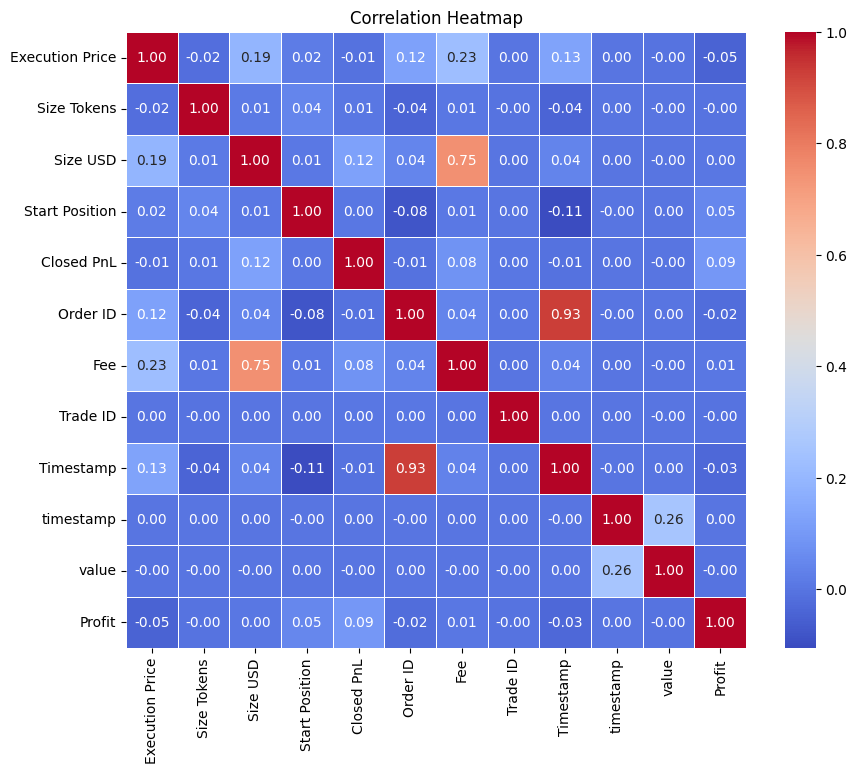

In [ ]:
# Visualization
#Correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

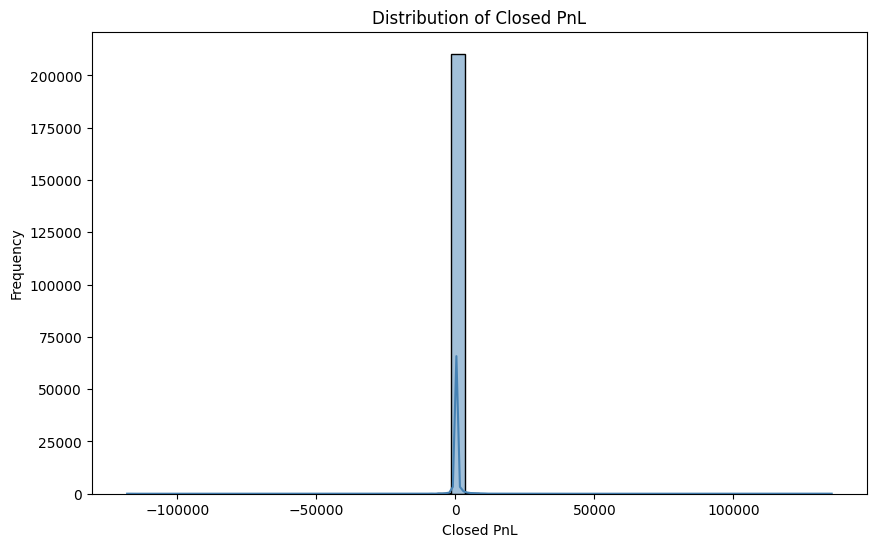

In [ ]:
# Histrogram of Closed PnL
plt.figure(figsize=(10,6))

sns.histplot(
    df['Closed PnL'],
    bins=50,
    kde=True,
    color='steelblue'
)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.show()

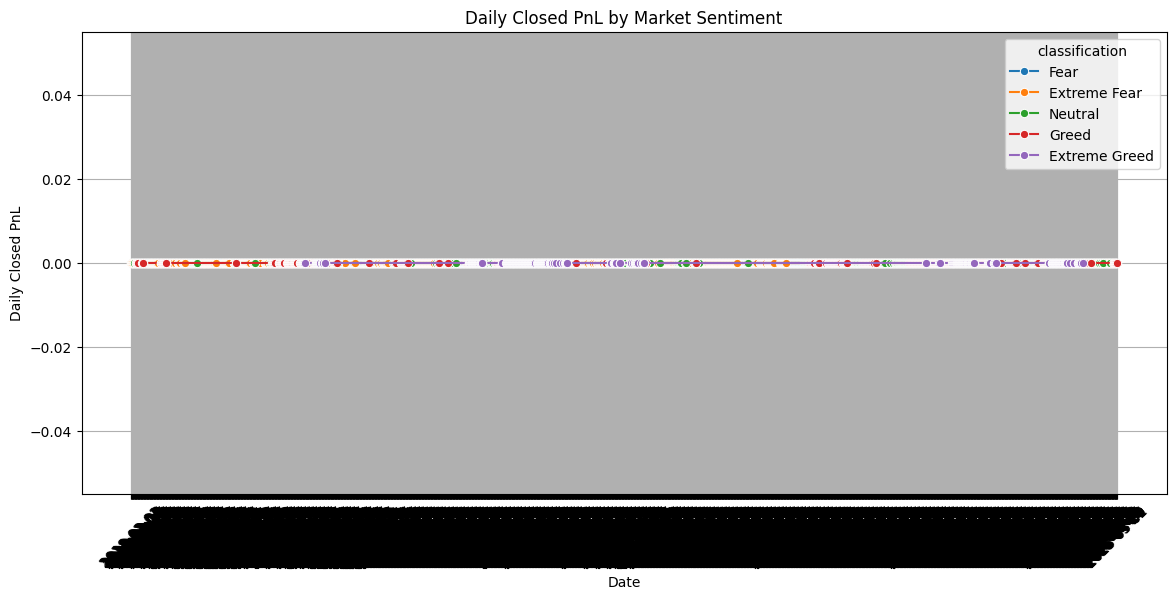

In [ ]:
daily_sentiment = df.groupby(
    ['date', 'classification']
)['Closed PnL'].sum().reset_index()

plt.figure(figsize=(14,6))

sns.lineplot(
    data=daily_sentiment,
    x='date',
    y='Closed PnL',
    hue='classification',
    marker='o'
)

plt.title("Daily Closed PnL by Market Sentiment")
plt.xlabel("Date")
plt.ylabel("Daily Closed PnL")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()